# Atlantic benchmark: SCOTIA wind/thermohaline decomposition

This reproduces the established Cape Agulhas-to-SPNA experiment through the
new global, non-ITF API. It introduces no new forcing interpretation.

**Geometry.** GEBCO 1000 m; Atlantic diagnostics from the Agulhas gateway
$y_I\approx35^\circ$S to $55^\circ$N. The global solve retains the closed
Indian and Pacific basins.

**Total experiment.** ERA5 stress anomalies are converted upstream to
$\mathbf{M}_{\mathrm{Ek}}$; SCOTIA is the total northern transport.

**Wind component.** The same $\mathbf{M}_{\mathrm{Ek}}$, with northern and southern
boundary transports equal to its own Ekman sections.

**Thermohaline component.** Total minus wind. By linearity this is equivalent
to zero $\mathbf{M}_{\mathrm{Ek}}$ forced at the north by SCOTIA minus the local
Ekman section. The three components close exactly apart from roundoff.

Here $h_b$ is evaluated at $x_b$, outside the western boundary-current region
rather than at the coastline; $h_w$ is the western-boundary thickness, not a
westward-propagating thickness. The transport diagnostic follows the legacy
$T_{\mathrm{no\ Ek}}$ convention, i.e. the geostrophic component.

Only Hovmöller/contour diagnostics are shown—no spectra and no bank of line
plots.

In [1]:
from pathlib import Path
import os
import sys
import warnings

import cmocean
import dask
from dask.array.core import PerformanceWarning
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "notebooks"))
DATA_ROOT = Path(os.environ["MOC_EXAMPLE_DATA_ROOT"])

from moc_adjustment_theory import GlobalAdjustmentModel, GlobalForcing
from _example_helpers import (
    ekman_transport_from_stress,
    non_itf_geometry,
    plot_geometry,
    regularization_gamma,
    section_transport,
)

plt.rcParams.update({"figure.dpi": 115, "axes.grid": False})
warnings.filterwarnings("ignore", category=PerformanceWarning)

## Geometry and SCOTIA forcing

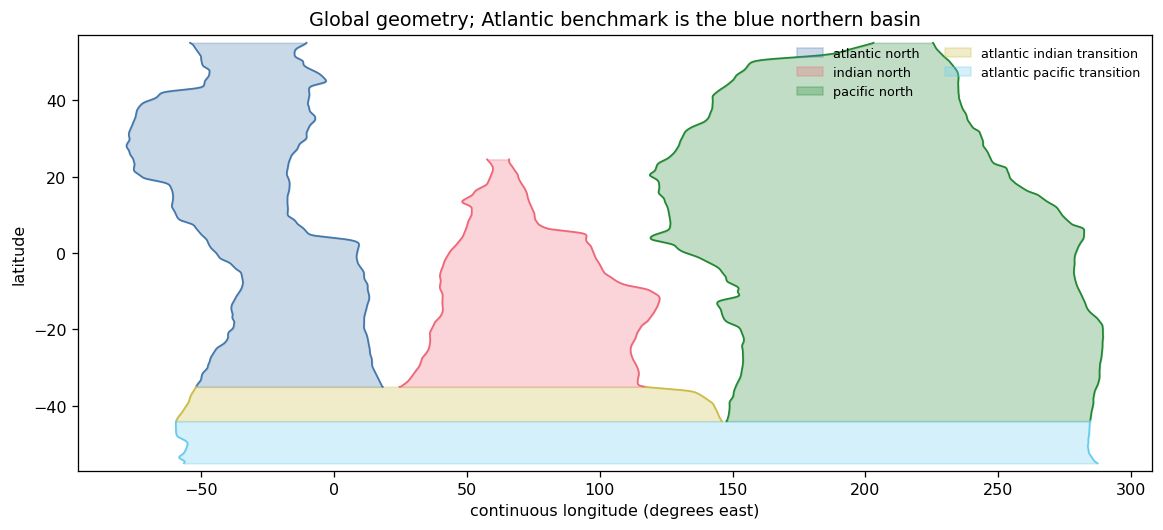

In [2]:
scotia = xr.open_dataset(
    DATA_ROOT / "SCOTIA/SCOTIA_overturning_diagnostics.nc"
).moc
scotia = scotia.assign_coords(time=scotia.time - np.timedelta64(14, "D"))
scotia.attrs["units"] = "Sv"

isobaths = xr.open_dataset(
    REPO / "data/tracked/isobath/global_isobath_GEBCO_1000m.nc"
).dropna("latitude", how="all")

def common_support(*names):
    traces = [isobaths[name].dropna("latitude") for name in names]
    return (
        max(float(trace.latitude[0]) for trace in traces),
        min(float(trace.latitude[-1]) for trace in traces),
    )

y_I, y_NI_raw = common_support("x_wI", "x_eI")
y_P, _ = common_support("x_wP", "x_eP")
y_S, y_N, y_NI, y_NP = -55.0, 55.0, 24.5, 55.0
geometry = non_itf_geometry(
    isobaths,
    y_S=y_S,
    y_P=y_P,
    y_I=y_I,
    y_N=y_N,
    y_NI=y_NI,
    y_NP=y_NP,
)

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_geometry(geometry, ax=ax)
ax.set(
    title="Global geometry; Atlantic benchmark is the blue northern basin",
    ylim=(y_S - 2, y_N + 2),
)
plt.show()

## Upstream ERA5 conversion and two linear model runs

In [3]:
winds = xr.open_dataset(
    DATA_ROOT / "ERA5/global_winds.nc",
    chunks={},
)[["avg_iews", "avg_inss"]]
winds = winds.assign_coords(
    valid_time=winds.valid_time - np.timedelta64(6, "h")
).rename(valid_time="time")
winds = winds.sel(latitude=slice(y_N, y_S)).sortby("latitude")
winds = winds.sel(time=scotia.time).chunk(
    {"time": -1, "latitude": 24, "longitude": 96}
)
stress_anomaly = winds - winds.mean("time")

rho_0 = 1027.0  # explicitly upstream
g_prime = 0.02
gamma = regularization_gamma(g_prime, geometry.H)
M_ek = ekman_transport_from_stress(
    stress_anomaly,
    geometry,
    rho_0=rho_0,
    gamma=gamma,
    width_degrees=2.0,
)
T_ek_north = section_transport(
    M_ek.M_ek_y,
    geometry,
    region="atlantic_north",
    latitude=y_N,
)
T_ek_south = section_transport(
    M_ek.M_ek_y,
    geometry,
    region="atlantic_pacific_transition",
    latitude=y_S,
)

def solve(northern_transport, southern_transport):
    forcing = GlobalForcing.from_time_series(
        M_ek_x=M_ek.M_ek_x,
        M_ek_y=M_ek.M_ek_y,
        northern_transport=northern_transport,
        southern_transport=southern_transport,
        sample_interval_seconds=365.25 * 86_400 / 12,
        padding_samples=scotia.sizes["time"] - 1,
        n_fft=2048,
    )
    return GlobalAdjustmentModel(geometry, forcing, g_prime=g_prime).solve()

with dask.config.set(scheduler="threads", num_workers=2):
    total_output = solve(scotia, T_ek_south)
    wind_output = solve(T_ek_north, T_ek_south)

thermohaline = total_output.dataset - wind_output.dataset
components = {
    "thermohaline": thermohaline,
    "wind": wind_output.dataset,
    "total": total_output.dataset,
}

## Cape Agulhas-to-SPNA decomposition

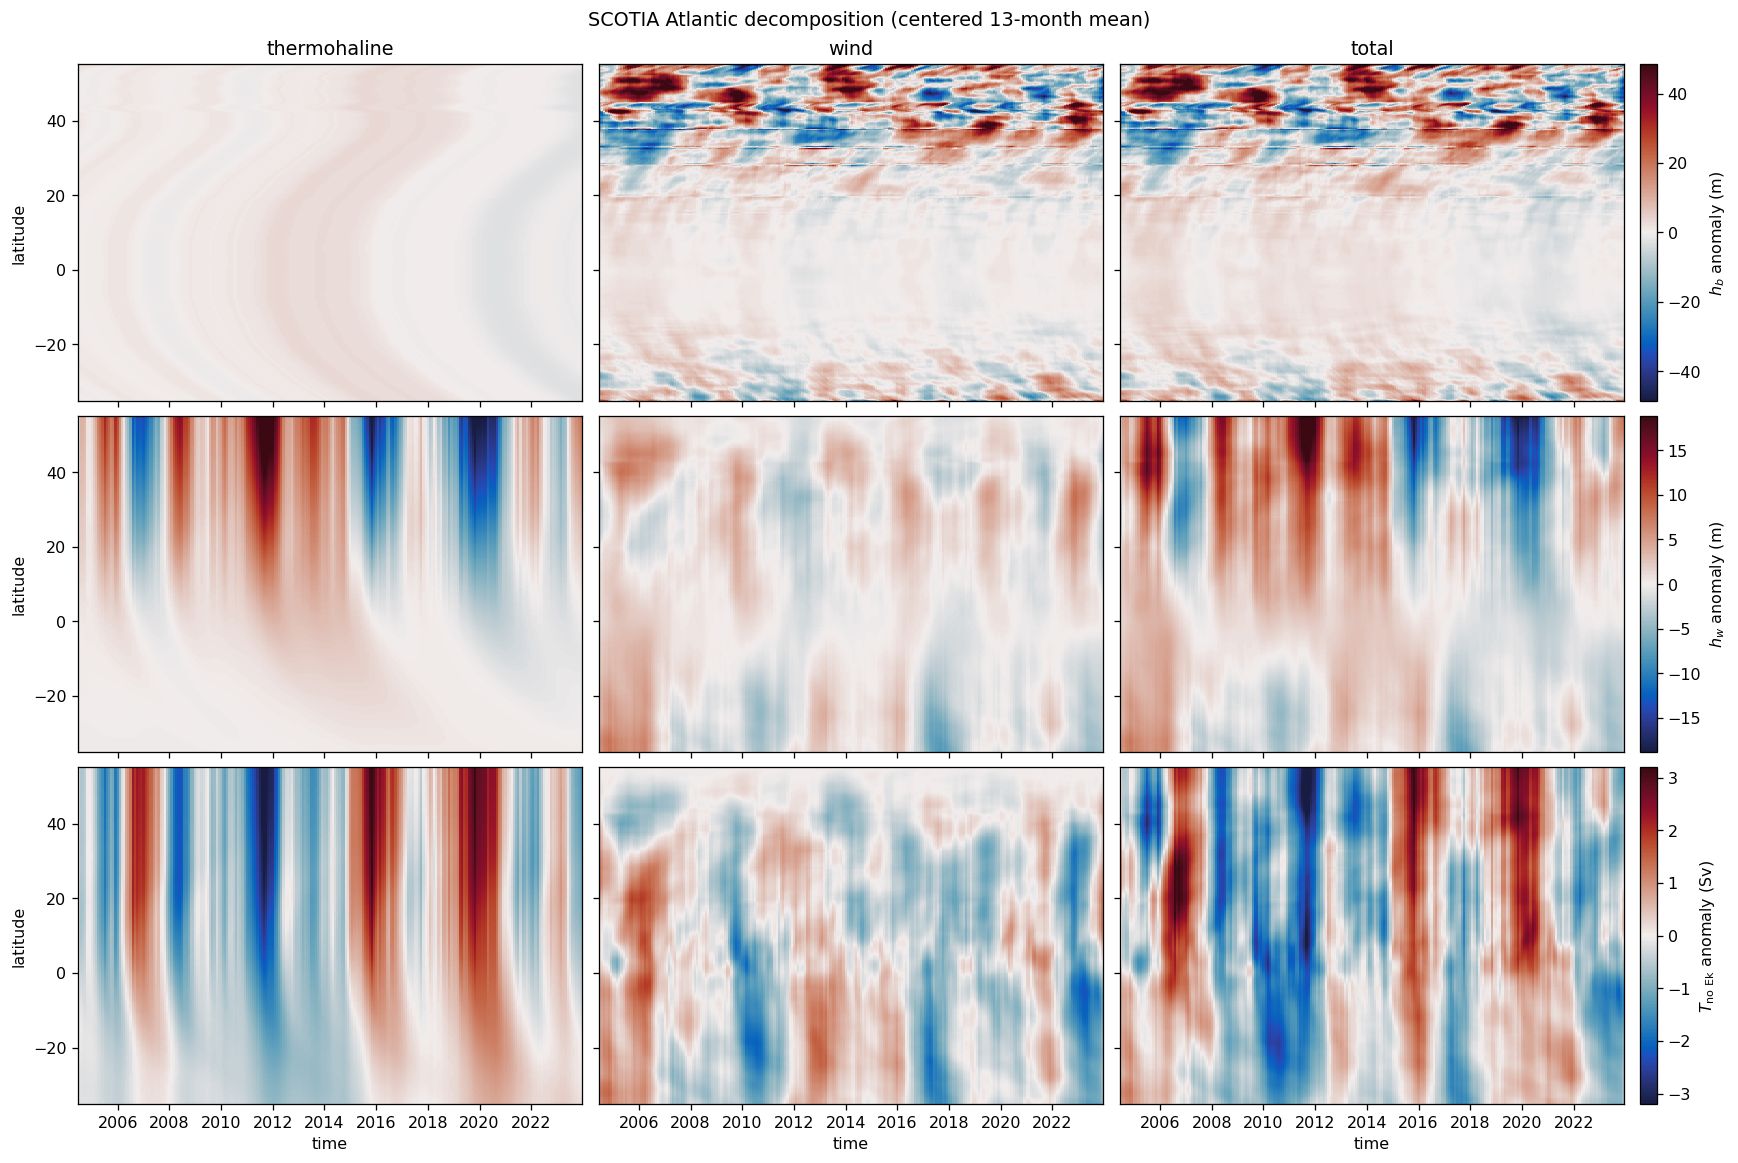

In [4]:
window_months = 13

def atlantic_field(dataset, name):
    field = dataset[name].sel(region="atlantic_north").dropna("latitude", how="all")
    if name.startswith("transport"):
        field = field / 1e6
    return field.rolling(time=window_months, center=True).mean().dropna("time")

field_specs = [
    ("h_b", r"$h_b$ anomaly (m)"),
    ("h_w", r"$h_w$ anomaly (m)"),
    ("transport_geostrophic", r"$T_{\mathrm{no\ Ek}}$ anomaly (Sv)"),
]
component_names = list(components)
fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 10),
    sharex=True,
    sharey="row",
    constrained_layout=True,
)
for row, (field_name, colorbar_label) in enumerate(field_specs):
    row_fields = [
        atlantic_field(components[component], field_name)
        for component in component_names
    ]
    vmax = max(float(abs(field).quantile(0.995)) for field in row_fields)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    for column, (component, field) in enumerate(zip(component_names, row_fields)):
        ax = axes[row, column]
        mesh = field.plot.pcolormesh(
            ax=ax,
            x="time",
            y="latitude",
            cmap=cmocean.cm.balance,
            norm=norm,
            add_colorbar=False,
            rasterized=True,
        )
        ax.set(
            xlabel="",
            ylabel="latitude" if column == 0 else "",
            title="",
        )
        if row == 0:
            ax.set_title(component)
    fig.colorbar(mesh, ax=axes[row, :], pad=0.01, label=colorbar_label)
for ax in axes[-1, :]:
    ax.set_xlabel("time")
fig.suptitle(
    f"SCOTIA Atlantic decomposition (centered {window_months}-month mean)"
)
plt.show()

## Linearity check

In [5]:
closure = {}
for name in ("h_b", "h_w", "transport_geostrophic"):
    reconstructed = thermohaline[name] + wind_output.dataset[name]
    closure[name] = float(abs(total_output.dataset[name] - reconstructed).max())
units = {"h_b": "m", "h_w": "m", "transport_geostrophic": "m3 s-1"}
print("maximum absolute closure error")
for name, value in closure.items():
    print(f"  {name:9s} {value:.3e} {units[name]}")

maximum absolute closure error
  h_b       8.882e-16 m
  h_w       7.105e-15 m
  transport_geostrophic 9.313e-10 m3 s-1
